In [10]:
import numpy as np, healpy as hp
from matplotlib import pyplot as plt
from astropy.table import Table, vstack

In [11]:
path = '/home/s/shuang92/rubin-user/Monster_guide'  ## RSP path

#path = '/sdf/home/s/shuang92/rubin-user/Monster_guide' ## S3DF path

##### 

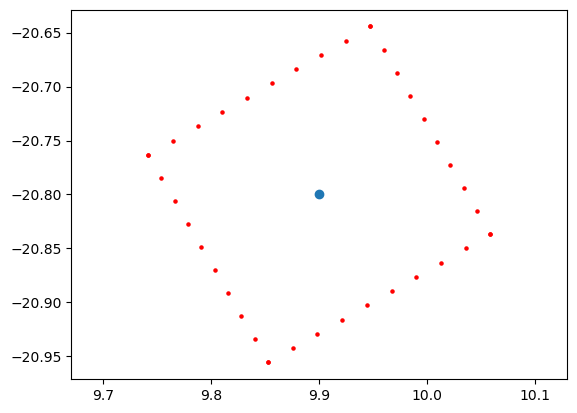

In [22]:
res = 5
nside = 2**res
npix = 12 * nside**2

ra = 9.9   ## in degrees
dec = -20.8   ## in degrees

# ra = 10     ## in degrees
# dec = -20   ## in degrees
theta = np.radians(30.0)    ## in radians

half_size_dec = 2000*0.2/3600                            ## in degrees
half_size_ra = half_size_dec/np.cos(np.radians(dec))     ## in degrees

## ccd corners but centered at ra, dec = 0,0
corners = [ [-half_size_ra, half_size_dec], [half_size_ra, half_size_dec], \
           [half_size_ra, -half_size_dec], [-half_size_ra, -half_size_dec] ]
corners.append(corners[0])
corners = np.array(corners)

## sides of one ccd but centered at 0,0
sides = [ [np.linspace(corners[i][0], corners[i+1][0], 10), np.linspace(corners[i][1], corners[i+1][1], 10)] for i in range(4)] 
rotmat = np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])
sides = [ rotmat@side for side in sides]


plt.scatter(ra, dec)
for side in sides:
    plt.scatter(side[0]+ra, side[1]+dec, c='r', s=5)

plt.axis('equal')
plt.show()

In [23]:
hp_ind = [hp.ang2pix(nside, ra, dec, lonlat=True)]

for side in sides:
    hp_ind += list(np.unique(hp.ang2pix(nside, side[0]+ra, side[1]+dec, lonlat=True)))

hp_ind = np.unique(np.array(hp_ind))

print(hp_ind)

[8131 8259 8260 8387]


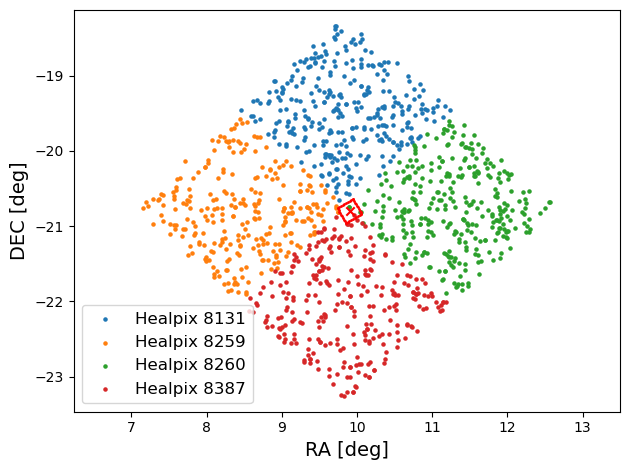

In [24]:
ref_cat = Table()

for ind in hp_ind:
    hp_table = Table.read(f'{path}/{ind}.csv')
    plt.scatter(hp_table['coord_ra']/np.pi*180, hp_table['coord_dec']/np.pi*180, s=5, label=f'Healpix {ind}')

    ref_cat = vstack([ref_cat, hp_table])


plt.axis('equal')
plt.legend(fontsize=12)
plt.xlabel('RA [deg]', fontsize=14)
plt.ylabel('DEC [deg]', fontsize=14)

plt.scatter(ra, dec, c='r', marker='x')
for side in sides:
    plt.scatter(side[0]+ra, side[1]+dec, c='r', s=1)

plt.tight_layout()
plt.show()

## Select good guide stars

### OCS should try to select a good star in current band. If no stars available in current band, try the Gaia G band. A star is a good guide star in a band when:
### 1. it has a synthetic LSST magnitude brighter than a mag cut, excluding NaN mags
### 2. it has no neighbors within the ROI brighter than mag cut + 2, excluding NaN mags

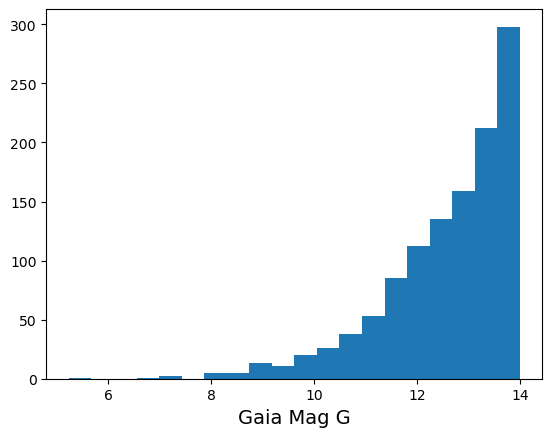

In [6]:
gaia_flag = ref_cat['guide_flag'] > 63
good_gaia = ref_cat[gaia_flag]

plt.hist(good_gaia['gaia_G'], bins=20)
plt.xlabel('Gaia Mag G', fontsize=14)
plt.show()

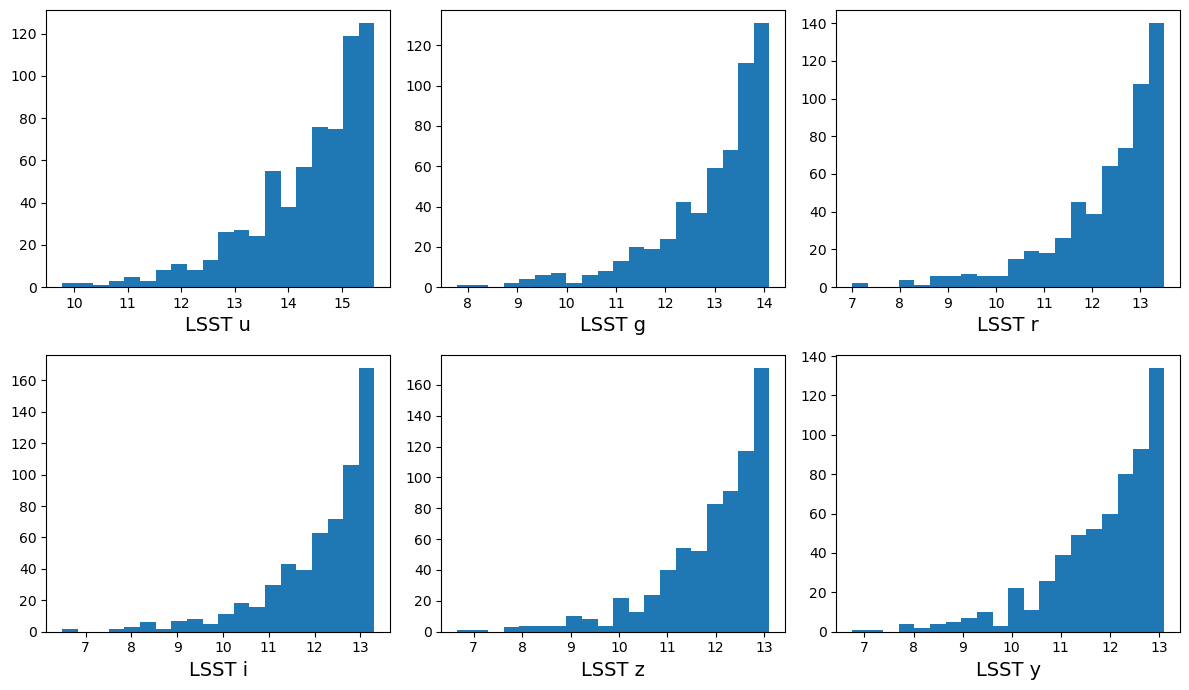

In [7]:
y_flag = (ref_cat['guide_flag'] % 64) > 31
z_flag = (ref_cat['guide_flag'] % 32) > 15
i_flag = (ref_cat['guide_flag'] % 16) > 7
r_flag = (ref_cat['guide_flag'] % 8) > 3
g_flag = (ref_cat['guide_flag'] % 4) > 1
u_flag = (ref_cat['guide_flag'] % 2) > 0

flags = {'u':u_flag, 'g':g_flag, 'r':r_flag, 'i':i_flag, 'z':z_flag, 'y':y_flag}


fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for b, ax in zip('ugrizy', axes.flatten()):

    good_stars = ref_cat[flags[b]]
    ax.hist(good_stars[f'mag_{b}'], bins=20)
    ax.set_xlabel(f'LSST {b}', fontsize=14)

plt.tight_layout()
plt.show()